# Step 2a — Basic swap test in Qiskit

Goal: build the minimal swap-test circuit (ancilla + test qubit + one training qubit, no index/label registers), and check that the fidelity it gives matches `fidelity()` from `closed_form_kernel.py` (Step 1) for the same pair of states.

This is the circuit-building equivalent of Eq. (8)/(9) for a single training point (M=1), n=1.

In [1]:
import numpy as np

from closed_form_kernel import training_data, test_state, fidelity
from circuit_kernel import swap_test_circuit, fidelity_from_circuit

## Sanity check: inspect the circuit

Before trusting any numbers, draw the circuit and make sure it visually matches what you intended: H, controlled-SWAP, H, with the two states initialized on the right qubits.

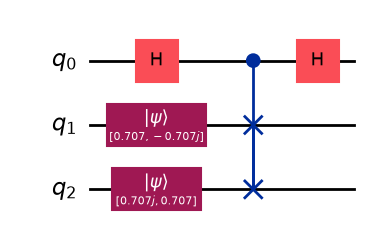

In [2]:
x1, y1, x2, y2 = training_data()
theta = 1.57

qc = swap_test_circuit(test_state(theta), x1)
qc.draw('mpl')

## Single-point check

Compare `fidelity_from_circuit` against `fidelity` from Step 1, at the same theta you hand-checked earlier (theta = 1.57).

In [3]:
circuit_fid = fidelity_from_circuit(test_state(theta), x1)
closed_form_fid = fidelity(test_state(theta), x1)

print('circuit    :', circuit_fid)
print('closed-form:', closed_form_fid)

assert np.isclose(circuit_fid, closed_form_fid), "circuit and closed-form fidelity disagree"

circuit    : 0.9999998414659164
closed-form: 0.9999998414659174


## Full theta sweep, against x1 and against x2

Once the single point matches, sweep theta and check the *whole curve* against the closed-form fidelity, for both training states. This is a much stronger check than one point -- it would catch e.g. a sign error that only shows up for some thetas.

In [4]:
thetas = np.linspace(0, 6, num=40)  # keep small while debugging -- each point runs a circuit

circuit_fid_x1 = np.array([fidelity_from_circuit(test_state(t), x1) for t in thetas])
closed_fid_x1  = np.array([fidelity(test_state(t), x1) for t in thetas])

circuit_fid_x2 = np.array([fidelity_from_circuit(test_state(t), x2) for t in thetas])
closed_fid_x2  = np.array([fidelity(test_state(t), x2) for t in thetas])

assert np.allclose(circuit_fid_x1, closed_fid_x1), "mismatch for x1"
assert np.allclose(circuit_fid_x2, closed_fid_x2), "mismatch for x2"
print('Circuit matches closed-form fidelity across the full sweep, for both training states.')

Circuit matches closed-form fidelity across the full sweep, for both training states.


## Next: Step 2b

Once this notebook runs clean, the next step is extending `circuit_kernel.py` to the full toy-example circuit (Fig. 6): add the index qubit (carrying the weights w1, w2) and the label qubit, so the circuit reproduces `expectation_value()` directly -- not just a single fidelity -- exactly as Eq. (9) does.

In [5]:
from circuit_kernel import expectation_value_from_circuit

theta = np.linspace(0, 6, num=40)
fidelities = [expectation_value_from_circuit(t) for t in theta]

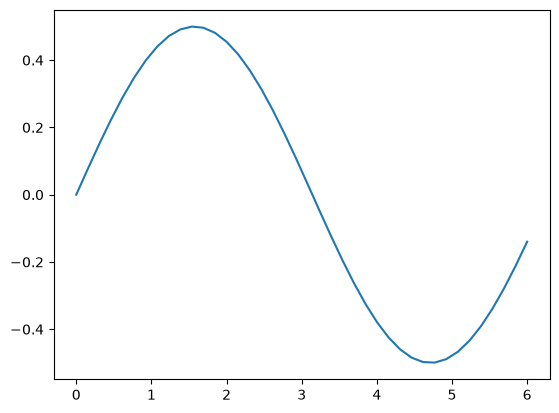

In [6]:
import matplotlib.pyplot as plt
plt.plot(theta, fidelities)